In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
# Read data
df = pd.read_csv("Advertising.csv")
dfs = df.iloc[:5,] # Subset first 5 rows
dfs

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
def obj(w):
    m1, m2, m3, b = w
    tv = dfs.loc[:, 'TV'].values
    radio = dfs.loc[:, 'Radio'].values
    news = dfs.loc[:, 'Newspaper'].values
    y = dfs.loc[:,'Sales'].values
    pred_Sales = (m1 * tv) + (m2 * radio) + (m3 * news) + b

    return ((pred_Sales - y) ** 2).mean()

In [4]:
# Calculuate values to minimize distance to best fit
res = minimize(obj, x0 = [0, 0, 0, 0])
res.x

array([ 0.07054428,  0.23961653, -0.04017871, -0.1419681 ])

In [5]:
# Prepare data for plotting
optimized_m1, optimized_m2, optimized_m3, optimized_b = res.x
tv_data = dfs['TV'].values
radio_data = dfs['Radio'].values
news_data = dfs['Newspaper'].values
actual_sales = dfs['Sales'].values
predicted_sales = (optimized_m1 * tv_data) + (optimized_m2 * radio_data) + (optimized_m3 * news_data) + optimized_b

predicted_sales

array([22.36741001, 10.60212241,  9.28540776, 18.09119926, 12.85386052])

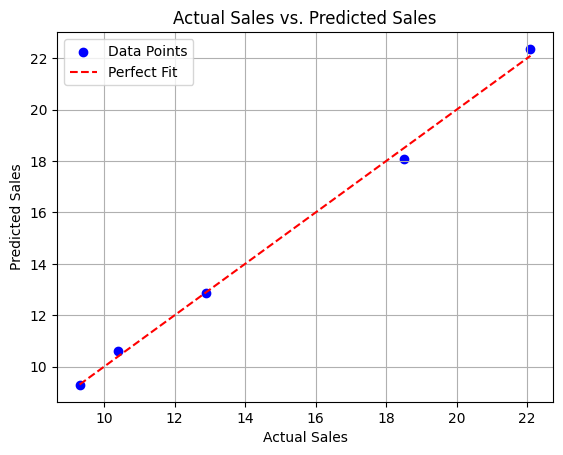

In [6]:
plt.scatter(actual_sales, predicted_sales, color='blue', label='Data Points')

perfect_line = np.linspace(min(actual_sales), max(actual_sales), 100) # return evenly spaced numbers over a specified interval
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', label='Perfect Fit')

plt.title('Actual Sales vs. Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.grid(True)
plt.show()